# **GridWorld Reinforcement Learning**
## From Tabular Q-Learning to Deep Q-Networks

---

### **Introduction**
Reinforcement learning algorithms range from simple tabular methods to deep neural network-based approaches. In this project, we implement both a classical Tabular Q-Learning agent and a Deep Q-Network (DQN) agent on the same custom GridWorld environment.

---

### **The Environment**
Our environment is a simple 5x5 GridWorld from a start position to a goal, with walls. The agent can choose to go up, down, left & right on each state.
```
S . . . .
. X . X .
. X . . .
. . X . .
. . . . G
```
- `S`: Start position
- `G`: Goal state
- `X`: Wall (blocked cell with punishment)
- `.`: Free space

In [ ]:
class GridWorld:
    def __init__(self):
        self.rows = 5
        self.cols = 5

        self.start = (0, 0)
        self.goal = (4, 4)

        self.agent_pos = self.start

        self.actions = {
            0: (-1, 0),  # up
            1: (1, 0),  # down
            2: (0, -1),  # left
            3: (0, 1),  # right
        }

        self.walls = {(1, 1), (1, 3), (2, 1), (3, 2)}

As implemented below, every step generates a reward of **-1**. Motivating the agent to reach the goal state ASAP.
- Moving out of border generates a reward of **-5**.
- Bumping into walls generates a reward of **-10**. 
- Reaching the goal state generates a reward of **+100**.

In [1]:
def step(self, action):

    dr, dc = self.actions[action]

    row, col = self.agent_pos

    new_row = row + dr
    new_col = col + dc

    reward = -1
    done = False

    # check bounds
    if not (0 <= new_row < self.rows and 0 <= new_col < self.cols):
        return self.agent_pos, -5, False

    # check walls
    if (new_row, new_col) in self.walls:
        return self.agent_pos, -10, False

    # move agent
    self.agent_pos = (new_row, new_col)

    # goal
    if self.agent_pos == self.goal:
        return self.agent_pos, 100, True

    return self.agent_pos, reward, done

---

## **Tabular Q-Learning**
Since the environment contains a small and finite number of states, it is natural to first solve it using the Tabular Q-Learning algorithm. The agent maintains a Q-table that stores the estimated value of every state-action pair and updates it after every interaction with the environment.

$Q(s, a) ← Q(s, a) + α [ r + γ max Q(s', a') − Q(s, a) ]$

Where:
- `α` = learning rate
- `γ` = discount factor
- `ε` = exploration rate (ε-greedy policy)

#### **Q-Learning agent:**

In [2]:
class QLearningAgent:
    def __init__(self, env):

        self.alpha = 0.1
        self.gamma = 0.99
        self.epsilon = 0.1

        self.q_table = np.zeros((env.rows, env.cols, 4))

#### **Q-Learning implementation:**

In [3]:
def learn(self, state, action, reward, next_state, done):

    row, col = state
    n_row, n_col = next_state

    current_q = self.q_table[row, col, action]

    if done:
        target = reward
    else:
        target = reward + self.gamma * np.max(self.q_table[n_row, n_col])

    self.q_table[row, col, action] = current_q + self.alpha * (target - current_q)

#### **Training loop:**

In [ ]:
for episode in range(episodes):

    state = env.reset()
    done = False

    steps = 0
    while not done:

        action = agent.choose_action(state)

        next_state, reward, done = env.step(action)

        agent.learn(state, action, reward, next_state, done)

        state = next_state

        steps += 1

    episode_steps.append(steps)
    if episode % 50 == 0:
        print(f"Episode {episode}, steps = {steps}")

#### **Results:**



**Learned policy:**
```
S → ↓ ← ↓ 
↓ X ↓ X ↓ 
↓ X → → ↓ 
→ ↓ X ↓ ↓ 
→ → → → G 
```

**Steps per episode plot:**

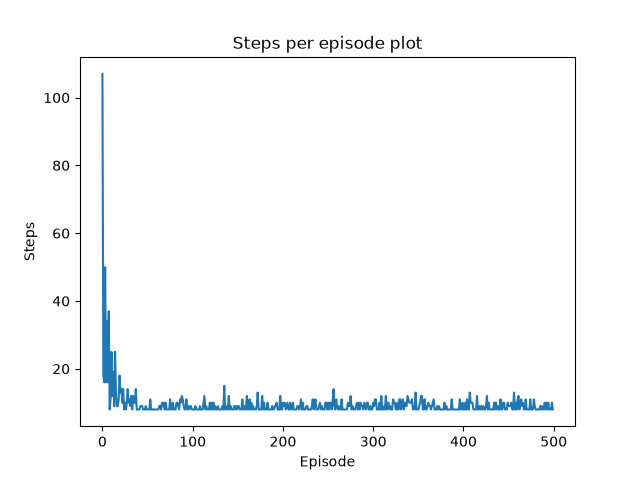

In [5]:
from IPython.display import Image, display
display(Image(filename="../outputs/qlearning_steps_per_episode.png"))

As training progresses, the number of steps required to reach the goal decreases consistently, indicating that the agent is learning an increasingly efficient policy. Eventually, the learned policy enables the agent to reach the goal in the minimum possible number of moves. Indicating that it is indeed the optimal policy.

---

While Tabular Q-Learning performs very well in small environments, it does not scale to large state spaces because it requires storing a value for every state-action pair.

Deep Q-Networks address this limitation by replacing the Q-table with a neural network capable of approximating the action-value function.

To better understand the differences between these approaches, the next step was to replace the tabular representation with a DQN while keeping the environment unchanged.

---

## **Deep Q-Network**

In Deep Q-Learning, the **neural network** approximates the action-value function Q(s,a).

Instead of storing a Q-table (which becomes infeasible for large or continuous state spaces), the network takes a state s as input and outputs a vector of Q-values for all possible actions:

#### **The Neural Network Architecture:**
To approximate the Q-values for our agent, we use a standard Multi-Layer Perceptron (MLP) implemented in PyTorch. The network takes the environment state as input and outputs the estimated Q-values for each possible action.

In [ ]:
import torch
import torch.nn as nn

class DQN(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 4)

    def forward(self, x):

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x


The input size is 2 (representing the agent's 2D coordinates in the GridWorld), and the output size is 4 (representing the discrete actions: up, down, left, right).

#### **Experience Replay Buffer:**
In standard reinforcement learning, consecutive experiences are highly correlated, which can destabilize neural network training. To mitigate this, we implement a Replay Buffer. The replay buffer stores past experiences as tuples:
```
(s,a,r,s',done)
```
Instead of learning from consecutive steps, the agent samples a random batch from this buffer to train. satisfying the i.i.d. assumption required for stable gradient decent.

In [ ]:
from collections import deque
import random

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, experience):
        self.buffer.append(experience)

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

#### **DQN Agent:**
The DQNAgent class encapsulates the decision-making policy and the learning algorithm. It utilizes two identical networks (Online and Target) to stabilize the learning of the Q-function.

In [ ]:
import torch.optim as optim

class DQNAgent:
    def __init__(self, gamma, epsilon, buffer_capacity):
        self.gamma = gamma
        self.epsilon = epsilon

        # Initialize primary and target networks
        self.online_network = DQN()
        self.target_network = DQN()
        self.target_network.load_state_dict(self.online_network.state_dict())

        self.replay_buffer = ReplayBuffer(capacity=buffer_capacity)
        self.optimizer = optim.Adam(self.online_network.parameters(), lr=0.001)
        self.loss_function = nn.MSELoss()

    def choose_action(self, state):
        # Epsilon-greedy strategy for exploration vs exploitation
        if random.random() < self.epsilon:
            return random.randint(0, 3) # Explore

        state = torch.FloatTensor(state)
        q_values = self.online_network(state)
        return torch.argmax(q_values).item() # Exploit

The agent uses an $\epsilon$-greedy policy for action selection. With probability $\epsilon$, it explores the environment randomly; otherwise, it exploits its current knowledge by choosing the action with the highest Q-value.

#### **Learning Mechanism:**
The learn method calculates the loss using the Bellman optimality equation. The target is defined as:

$$y = r + \gamma \max_{a'} Q_{target}(s', a')$$


We use the target network to calculate the next state's maximum Q-value to prevent moving targets, which causes training oscillation. The Mean Squared Error (MSE) is computed between the online network's prediction and this target.

In [ ]:
def learn(self, batch_size):
    if len(self.replay_buffer) < batch_size:
        return

    # Sample a mini-batch from the buffer
    batch = self.replay_buffer.sample(batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    # Convert to PyTorch tensors
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions)
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones)

    # Compute predicted Q-values for chosen actions
    current_q = self.online_network(states).gather(1, actions.unsqueeze(1))

    # Compute target Q-values using the Bellman Equation
    with torch.no_grad():
        next_q = self.target_network(next_states).max(dim=1)[0]
        
    target_q = rewards + self.gamma * next_q * (1 - dones)

    # Optimize the model
    loss = self.loss_function(current_q, target_q.unsqueeze(1)) # Ensure shape match
    self.optimizer.zero_grad()
    loss.backward()
    self.optimizer.step()

#### **Training Loop:**

This section orchestrates the interactions between the GridWorld environment and our DQN Agent, stepping through episodes and updating the network weights.

In [ ]:
env = GridWorld()
agent = DQNAgent(gamma=0.99, epsilon=0.1, buffer_capacity=10_000)

batch_size = 32
target_update = 20
episodes = 500
episode_steps = []

# Main Training Loop
for episode in range(episodes):
    state = env.reset()
    done = False
    steps = 0

    while not done:
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        
        # Store experience
        agent.replay_buffer.add((state, action, reward, next_state, done))

        # Train the online network
        agent.learn(batch_size)

        state = next_state
        steps += 1

    episode_steps.append(steps)
    
    # Progress logging
    if episode % 50 == 0:
        print(f"Episode {episode}, Steps: {steps}")

    # Update target network periodically
    if episode % target_update == 0:
        agent.update_target_network()

The agent interacts with the GridWorld for 500 episodes. In every single step, it chooses an action, receives a reward, stores the transition, and attempts to learn from a mini-batch of size 32.

Every 20 episodes, the weights of the stable target network are hard-updated to match the currently training online network.

#### **Results:**

**Learned policy:**
```
S → → ↓ ↓ 
↑ X ↓ X ↓ 
↓ X ↓ ↓ ↓ 
↓ ↓ X ↓ ↓ 
↑ → ↓ → G 
```

**Steps per episode plot:**

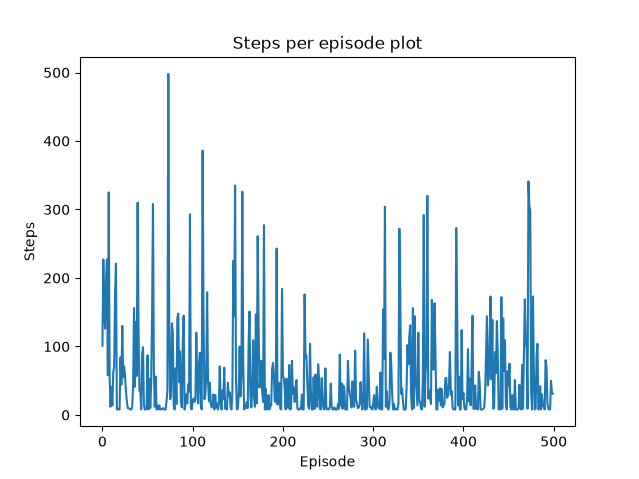

In [1]:
from IPython.display import Image, display
display(Image(filename="../outputs/experiment0:dqn_steps_per_episode.png"))

Looking at the steps-per-episode plot & the learned policy for the DQN agent, the results are highly unexpected and point to a significant issue in the learning process:
- **Lack of Convergence:** Unlike a typical reinforcement learning curve that trends downward as the agent learns the environment, this plot shows no clear signs of convergence. The agent consistently takes a large number of steps to finish an episode from start to finish.
- **Extreme Instability:** The training is highly erratic. While there are episodes where the agent finishes quickly, there are frequent, massive spikes where the agent takes 300, 400, and even over 600 steps to complete a single episode.
- **Inaccurate Policy:** By the 500th episode, the variance remains extremely high, indicating that the neural network has failed to approximate the correct Q-values. The resulting policy is essentially random or highly suboptimal.

---

The current DQN implementation is failing to learn a stable policy, and the performance is significantly worse than our expectations. The remainder of this project will be dedicated to diagnosing why this is happening and implementing fixes to stabilize the training.

---

### **Diagnosing the Problem**

By looking at the learned policy we observe that:
- It is not globally consistent. arrows don’t form a coherent flow field toward the goal. Multiple cells contradict shortest-path direction.
- It is not random either. it’s structured. So the network learned something but it’s wrong in a systematic way.

Overall, our policy has local consistency but global inconsistency.

---

### **Experiment 1: State Representation Problem**

The agent receives a state representation defined as: `state = (row, col)`

This means the network is effectively trying to learn Q(row, col). One hypothesis we are investigating is that by feeding raw coordinates, the model might be implicitly assuming a continuous geometric space:

(0,0) -> (0,1) -> (0,2) -> (0,3)

If true, this suggests the network assumes that moving in a direction (like right) always corresponds to a straightforward spatial progression. However, because our gridworld contains obstacles, the environment is actually structured like a graph, not a continuous plane. Therefore, the true distance between states is path-dependent, not Euclidean.

For example:

- (0,1) might be closer in raw coordinates.
- But if it is physically blocked by a wall, the actual shortest path is entirely different.

This might be creating a mismatch between the network’s learned geometry (a Euclidean bias) and the environment’s true graph-based topology. We plan to test this hypothesis next to see if addressing this mismatch stabilizes the policy. It might completely resolve the issue, or it might just be one piece of the puzzle.

#### **Proposed Fix: Goal-Conditioned State Representation**

To address the geometry mismatch, we modify the state representation to explicitly include goal information.

`New State = (row, col, goal_row, col_row)`

So rather than forcing the network the infer spatial relationships implicitly, we directly provide the relational structure:

$\text{directions} = goal - state$

This change, transforms the problem to learning how to act given a direction to the goal.


#### **Changes:**

#### ***1: Modify DQN input layer***

Since the input is now:
`[agent_row, agent_col, goal_row, goal_col]`

Before:

In [ ]:
nn.Linear(2, 64)

After:

In [ ]:
nn.Linear(4, 64)

#### ***2: Modify action selection***

Before:

In [ ]:
state = torch.FloatTensor(state)
# = ([r, c])

After:

In [ ]:
state = torch.FloatTensor([row, col, goal_row, goal_col])
# = ([r, c, goal_r, goal_c])

#### ***3: Modify learn() method***

Before:

In [ ]:
states = torch.FloatTensor(states)
next_states = torch.FloatTensor(next_states)

After:

In [ ]:
goal_row, goal_col = (4, 4)
states = torch.FloatTensor(
    [[row, col, goal_row, goal_col] for row, col in states]
)
next_states = torch.FloatTensor(
    [[row, col, goal_row, goal_col] for row, col in next_states]
)

#### **Results:**

**Learned policy:**

Episode 499, Steps: 47
```
S ↓ ↓ ↓ ↓ 
↓ X ↓ X ↓ 
↓ X ↓ ↓ ↓ 
↓ ↓ X ↓ ↓ 
↓ ↓ → → G 
```

**Steps per episode plot:**

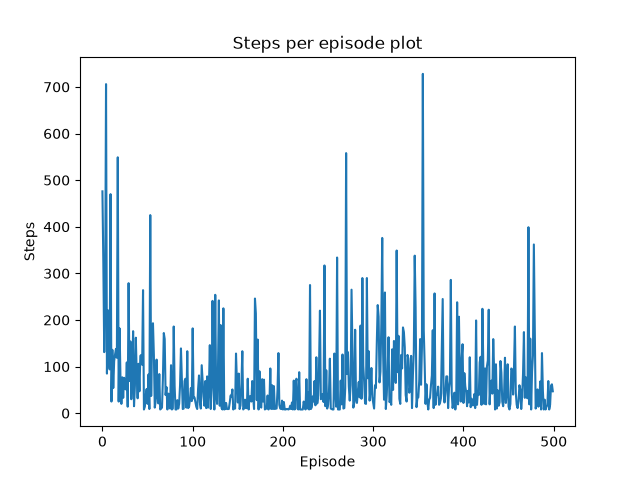

In [3]:
from IPython.display import Image, display
display(Image(filename="../outputs/experiment1:dqn_steps_per_episode.png"))

Unfortunately, The results showed no real improvement after adjusting how the agent sees the grid. While the performance went up slightly, the change was so small that it was likely just random chance. The policy is still failing to learn properly, so we need to look for the root cause elsewhere.

---

### **Experiment 2: Identifying the Gradient Anomaly**

Upon deeper inspection of the Bellman equation implementation, the root cause was identified as a silent tensor shape broadcasting anomaly in PyTorch.

**In learn() function in DQNAgent class:**

In [ ]:
# sample a batch
batch = self.replay_buffer.sample(batch_size)

# split the whole experience tuple
states, actions, rewards, next_states, dones = zip(*batch)

# convert to tensors
states = torch.FloatTensor(states)
actions = torch.LongTensor(actions)
rewards = torch.FloatTensor(rewards)
next_states = torch.FloatTensor(next_states)
dones = torch.FloatTensor(dones)

# compute current q-values & target q-values
current_q = self.online_network(states).gather(1, actions.unsqueeze(1))

# don't build a computation graph and don't compute gradients
with torch.no_grad():
    next_q = self.target_network(next_states).max(dim=1)[0]

# bellman equation
target_q = rewards + self.gamma * next_q * (1 - dones)

loss = self.loss_function(current_q, target_q)

self.optimizer.zero_grad()
loss.backward()
self.optimizer.step()

When we compute the `current_q` and `target_q` values:

```python
current_q = self.online_network(states).gather(1, actions.unsqueeze(1))
```
results in a tensor of shape `[batch_size, 1]`.

```python
next_q = self.target_network(next_states).max(dim=1)[0]
```
results in a tensor of shape `[batch_size]`.

And because `target_q` is derived from `next_q`, it also ends up with a shape of `[batch_size]`.

In:
```python
loss = self.loss_function(current_q, target_q)
```
The online network’s Q-value output shape of `[batch_size, 1]` was being evaluated against the target network’s Q-value shape of `[batch_size]`. Instead of a 1-to-1 mapping, the framework automatically broadcasted these tensors into a `[batch_size, batch_size]` matrix. This meant the loss was being calculated against every other experience in the batch simultaneously, completely diluting the gradients and preventing the network from learning the true Q-values.

#### **Proposed Fix: Goal-Conditioned State Representation**

Applying a simple dimensionality reduction `(.squeeze(-1))` to align the tensors immediately restored the integrity of the backpropagation.

Before:

In [ ]:
loss = self.loss_function(current_q, target_q)

After:

In [ ]:
current_q = current_q.squeeze(-1)
loss = self.loss_function(current_q, target_q)

#### **Results:**

**Learned policy:**
```
S → ↓ ← ← 
↓ X ↓ X ↓ 
↓ X → → ↓ 
→ ↓ X → ↓ 
→ → → → G 
```

**Steps per episode:**
```
Episode 0, Steps: 6494
Episode 10, Steps: 351
Episode 20, Steps: 146
Episode 30, Steps: 11
Episode 40, Steps: 8
Episode 50, Steps: 8
Episode 60, Steps: 8
Episode 70, Steps: 11
Episode 80, Steps: 9
Episode 90, Steps: 10
Episode 100, Steps: 8
Episode 110, Steps: 10
Episode 120, Steps: 8
Episode 130, Steps: 129
Episode 140, Steps: 142
Episode 150, Steps: 26
Episode 160, Steps: 150
Episode 170, Steps: 103
Episode 180, Steps: 68
Episode 190, Steps: 109
Episode 200, Steps: 124
Episode 210, Steps: 10
Episode 220, Steps: 20
Episode 230, Steps: 78
Episode 240, Steps: 83
Episode 250, Steps: 773
Episode 260, Steps: 495
Episode 270, Steps: 382
Episode 280, Steps: 567
Episode 290, Steps: 67
Episode 300, Steps: 49
Episode 310, Steps: 34
Episode 320, Steps: 26
Episode 330, Steps: 15
Episode 340, Steps: 36
Episode 350, Steps: 68
Episode 360, Steps: 46
Episode 370, Steps: 8
Episode 380, Steps: 10
Episode 390, Steps: 8
Episode 400, Steps: 14
Episode 410, Steps: 8
Episode 420, Steps: 10
Episode 430, Steps: 8
Episode 440, Steps: 9
Episode 450, Steps: 8
Episode 460, Steps: 10
Episode 470, Steps: 8
Episode 480, Steps: 10
Episode 490, Steps: 8
Episode 499, Steps: 9
```

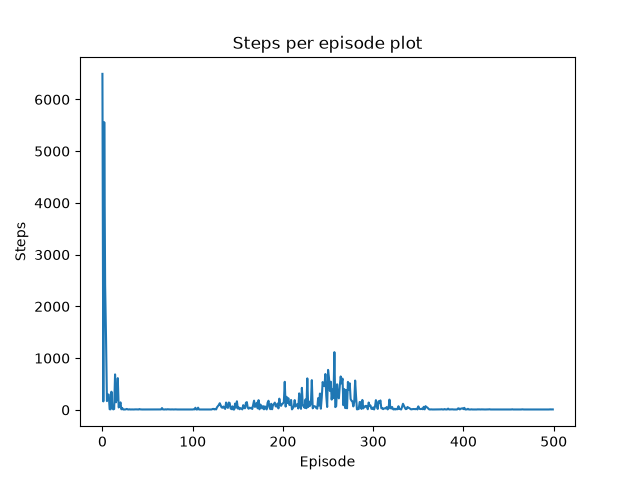

In [1]:
from IPython.display import Image, display
display(Image(filename="../outputs/experiment2:dqn_steps_per_episode.png"))

Following the correction of the tensor shape broadcasting anomaly in the loss calculation, the DQN agent was retrained.

- Initial Exploration: Episode 0 required a massive 6,494 steps. The agent was acting almost entirely randomly, wandering the grid until it finally stumbled upon the goal.

- Mid-Training Variance: Between episodes 150 and 300, the step count exhibits a period of high variance and occasional spikes (e.g., Episode 250 required 773 steps). This is an expected outcome of the epsilon-greedy strategy as the agent explores alternative, potentially riskier routes before solidifying its Q-values.

- Convergence: From episode 370 onward, the policy stabilizes. The agent consistently reaches the goal in 8 to 10 steps, indicating it has found the optimal path.

The output confirms that the agent successfully learned an optimal policy to navigate the 5x5 gridworld. The final policy clearly demonstrates the agent successfully routing around the grid's obstacles to reach the goal from the starting position.

**Next Steps**

**1.** The current architecture executes a full forward pass, loss calculation, and backpropagation on every single step, which caused this 500-episode run to take roughly **1.5 minutes**. To resolve this computational bottleneck, we will introduce a **step-skip mechanism**. The agent will continue to interact with the environment on every step, but the heavy learn() function will only be called every 4 steps.

**2.** The baseline experiment utilized a constant epsilon value for exploration. While this allowed the agent to eventually find the goal, it forced the agent to continue taking random, suboptimal actions even late in training (which accounts for the high variance and step-count spikes seen between episodes 150 and 300). To improve final policy stability, an **epsilon decay mechanism** will be implemented.

---

### **Experiment 3: Loop Optimization & Epsilon Decay**

#### **1. Step-Skip Loop Optimization**

In the previous baseline, the `agent.learn()` method was called during every single frame of the environment. This meant PyTorch was performing a full forward pass, calculating the Mean Squared Error (MSE) loss, and executing backpropagation for every step the agent took. During early episodes where the agent wandered for thousands of steps, this created an unnecessary and massive computational overhead.

To optimize execution time, a "step-skip" mechanism was introduced.

The agent still interacts with the environment and stores state transitions in the Replay Buffer on every single step, ensuring no data is lost. However, the computationally expensive neural network weight updates are only executed every 4th step.

#### **2. Dynamic Exploration with Epsilon Decay**

The initial agent utilized a static `epsilon = 0.1`. While a constant 10% exploration rate eventually allows the agent to find the goal, it forces the agent to continue taking random, suboptimal actions even late in training when it should be exploiting its learned Q-values. This static rate was the root cause of the step-count spikes observed in the late stages of Experiment 2.

The exploration strategy was upgraded to dynamic Epsilon Decay. The agent now initializes with `epsilon = 1.0` (100% pure exploration) to ensure it broadly maps the gridworld in the opening episodes. At the end of each episode, the epsilon value is multiplied by a decay factor of **0.985**, slowly reducing the exploration rate until it hits a floor of `epsilon_min = 0.05`.

The agent is forced to aggressively explore when its network is untrained, and dynamically shifts to exploiting the optimal policy as the Q-values stabilize over time, ensuring a much smoother and faster convergence without erratic late-stage behavior.

#### **Before:**

In [ ]:
env = GridWorld()
agent = DQNAgent(gamma=0.99, epsilon=0.1, buffer_capacity=10_000)

batch_size = 32
target_update = 20

episodes = 500
episode_steps = []
for episode in range(episodes):

    state = env.reset()
    done = False
    steps = 0

    while not done:
        # agent chooses the action with an epsilon-greedy fashion
        action = agent.choose_action(state)
        # agent takes that actions
        next_state, reward, done = env.step(action)
        # record the experience
        agent.replay_buffer.add((state, action, reward, next_state, done))

        # train after each new experience, but not based on the new experience
        if steps % 4 == 0:
            agent.learn(batch_size)

        state = next_state
        steps += 1

    episode_steps.append(steps)
    if episode % 10 == 0:
        print(f"Episode {episode}, Steps: {steps}")

    # update the target network every 20 episodes
    if episode % target_update == 0:
        agent.update_target_network()

#### **After:**

In [ ]:
env = GridWorld()
agent = DQNAgent(gamma=0.99, epsilon=1.0, buffer_capacity=10_000)

batch_size = 32
target_update = 20

episodes = 500
episode_steps = []

epsilon = 1.0  # Start with 100% exploration
epsilon_min = 0.05  # Never decay below 5% exploration
epsilon_decay = 0.985  # Decay rate per episode

train_frequency = 4  # Only run backprop every 4 steps

for episode in range(episodes):

    state = env.reset()
    done = False
    steps = 0
    agent.epsilon = epsilon

    while not done:
        # agent chooses the action with an epsilon-greedy fashion
        action = agent.choose_action(state)
        # agent takes that actions
        next_state, reward, done = env.step(action)
        # record the experience
        agent.replay_buffer.add((state, action, reward, next_state, done))

        # train after each new experience, but not based on the new experience
        if steps % train_frequency == 0:
            agent.learn(batch_size)

        state = next_state
        steps += 1

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    episode_steps.append(steps)
    if episode % 50 == 0:
        print(f"Episode {episode}, Steps: {steps}, Epsilon: {agent.epsilon:.2f}")

    # update the target network every 20 episodes
    if episode % target_update == 0:
        agent.update_target_network()

#### **Results:**

**Learned policy:**

```
S ← ← ← ← 
↓ X ← X ↓ 
↓ X → ↓ ↓ 
↓ ↓ X ↓ ↓ 
→ → → → G 
```

**Steps per episode:**

```
Episode 0, Steps: 39, Epsilon: 1.00
Episode 50, Steps: 12, Epsilon: 0.47
Episode 100, Steps: 8, Epsilon: 0.22
Episode 150, Steps: 8, Epsilon: 0.10
Episode 200, Steps: 8, Epsilon: 0.05
Episode 250, Steps: 9, Epsilon: 0.05
Episode 300, Steps: 8, Epsilon: 0.05
Episode 350, Steps: 8, Epsilon: 0.05
Episode 400, Steps: 9, Epsilon: 0.05
Episode 450, Steps: 9, Epsilon: 0.05
```

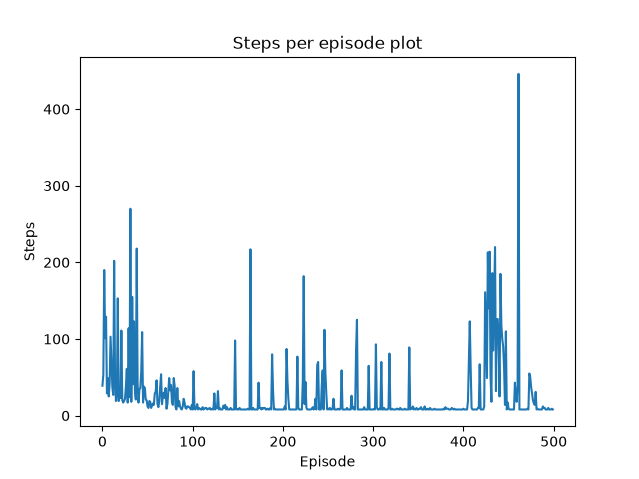

In [3]:
from IPython.display import Image, display
display(Image(filename="../outputs/experiment3:dqn_steps_per_episode.png"))

The agent successfully converged on a highly efficient, optimal policy. The terminal output demonstrates that the agent consistently reaches the goal in just 8 steps during stable periods. The learned grid shows a clean, obstacle-avoiding route.

- Unlike Experiment 2, which required over 6,000 steps in its first episode, the agent in Experiment 3 completed Episode 0 in just 39 steps. The decay mechanism rapidly guided the network toward exploitation; by Episode 100, the exploration rate dropped to 22% (Epsilon: 0.22), and the agent was already hitting the optimal 8-step path.

- Between episodes 100 and 400, the policy exhibits remarkable stability. As the epsilon value hits its floor of 0.05, the step count flatlines at 8 to 9 steps per episode, proving the agent has solidified its Q-values for the optimal route.

- Despite the sudden destabilization, the agent leveraged its replay buffer to quickly correct the erroneous Q-values. By episode 470, the agent fully recovered and returned to the optimal 8-step convergence.

**The most notable feature** of the graph is the massive spike in steps occurring around episodes 420 to 460, peaking at nearly 450 steps. Since the epsilon value during this period is locked at its minimum (0.05), this spike is not caused by random exploration. Instead, it is a classic example of **catastrophic forgetting** or a **destabilizing target network update**. A target network update (occurring every 20 episodes) likely shifted the Q-value estimations, causing the agent to temporarily unlearn its optimal path.

---